# 06 - Model Explainability

**Giải thích mô hình Machine Learning**
Các đánh giá classification đầy đủ như Precision, Recall, F1-score và Confusion Matrix đã được trình bày ở `04_classification.ipynb`.

Mục tiêu chính:

- Load dữ liệu từ MySQL view `vw_applications_ml_base`
- Train một mô hình Random Forest Classifier làm mô hình nền để giải thích
- Phân tích Feature Importance
- Phân tích Permutation Importance
- Rút ra nhận xét về những feature ảnh hưởng nhiều đến dự đoán


## 1. Import thư viện

In [1]:
import sys
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer

sys.path.append(os.path.abspath(".."))

from src.db_connection import get_engine

## 2. Load Data from MySQL

View `vw_applications_ml_base` giữ lại các đặc trưng gần với dữ liệu gốc và phù hợp để giải thích mô hình.

In [ ]:
engine = get_engine()

df = pd.read_sql("""SELECT * FROM vw_applications_ml_base""", engine)

print(df.shape)
df.head()

(239660, 20)


,appid,name,type,is_free,required_age,release_date,metacritic_score,recommendations_total,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_supports_windows,mat_supports_mac,mat_supports_linux,short_description,supported_languages,created_at,updated_at
0,10,Counter-Strike,game,0,0,2000-11-01,88.0,161854.0,999.0,999.0,0.0,USD,NaN,1,1,1,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
1,20,Team Fortress Classic,game,0,0,1999-04-01,NaN,6633.0,499.0,499.0,0.0,USD,NaN,1,1,1,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
2,30,Day of Defeat,game,0,0,2003-05-01,79.0,4308.0,499.0,499.0,0.0,USD,NaN,1,1,1,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
3,40,Deathmatch Classic,game,0,0,2001-06-01,NaN,2338.0,499.0,499.0,0.0,USD,NaN,1,1,1,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
4,50,Half-Life: Opposing Force,game,0,0,1999-11-01,NaN,22793.0,499.0,499.0,0.0,USD,NaN,1,1,1,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00


## 3. Chọn Features and Target

Nhóm chọn một số feature có ý nghĩa thực tế và dễ giải thích.  
Target được chọn là `mat_supports_linux`, dự đoán game có hỗ trợ Linux hay không.

In [ ]:
features = [
    "is_free",
    "metacritic_score",
    "recommendations_total",
    "mat_achievement_count",
    "mat_final_price"
]

target = "mat_supports_linux"
df_model = df[features + [target]].copy()
df_model.head()

,is_free,metacritic_score,recommendations_total,mat_achievement_count,mat_final_price,mat_supports_linux
0,0,88.0,161854.0,NaN,999.0,1
1,0,NaN,6633.0,NaN,499.0,1
2,0,79.0,4308.0,NaN,499.0,1
3,0,NaN,2338.0,NaN,499.0,1
4,0,NaN,22793.0,NaN,499.0,1


## 4. Check Target Distribution

Trước khi train model, cần kiểm tra phân bố của target. Nếu target bị mất cân bằng, Accuracy có thể cao nhưng chưa chắc phản ánh đầy đủ chất lượng mô hình.

In [4]:
df_model[target].value_counts()

mat_supports_linux
1    239360
0       300
Name: count, dtype: int64

In [5]:
df_model[target].value_counts(normalize=True) * 100

mat_supports_linux
1    99.874823
0     0.125177
Name: proportion, dtype: float64

## 5. Handle Missing Values

Các feature numeric có missing values được xử lý bằng median. Median phù hợp hơn mean trong trường hợp dữ liệu có outlier.

In [6]:
X = df_model[features]
y = df_model[target]

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

X_imputed = pd.DataFrame(
    X_imputed,
    columns=features
)

X_imputed.isnull().sum()

is_free                  0
metacritic_score         0
recommendations_total    0
mat_achievement_count    0
mat_final_price          0
dtype: int64

## 6. Train/Test Split

Dữ liệu được chia thành tập train và test. Tham số `stratify=y` giúp giữ tỷ lệ class giữa train và test tương đối giống nhau.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (191728, 5)
X_test: (47932, 5)


## 7. Train Random Forest Classifier

Random Forest được sử dụng vì mô hình này có khả năng cung cấp Feature Importance, giúp phân tích feature nào ảnh hưởng nhiều đến kết quả dự đoán.

Ở đây, mô hình được dùng chủ yếu để phục vụ mục tiêu **explainability**, không phải để thay thế notebook classification chính.

In [8]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 8. Quick Model Check

Chỉ sử dụng Accuracy để kiểm tra nhanh mô hình có học được tín hiệu từ dữ liệu hay không.  
Các đánh giá classification chi tiết đã được thực hiện ở notebook `04_classification.ipynb`.

In [ ]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8309062839021948


## 9. Feature Importance

Feature Importance cho biết mức độ đóng góp của từng feature trong mô hình Random Forest.  
Feature có importance cao hơn thường được mô hình sử dụng nhiều hơn để phân tách dữ liệu.

In [10]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
4,mat_final_price,0.378514
3,mat_achievement_count,0.366535
2,recommendations_total,0.150445
0,is_free,0.077184
1,metacritic_score,0.027323


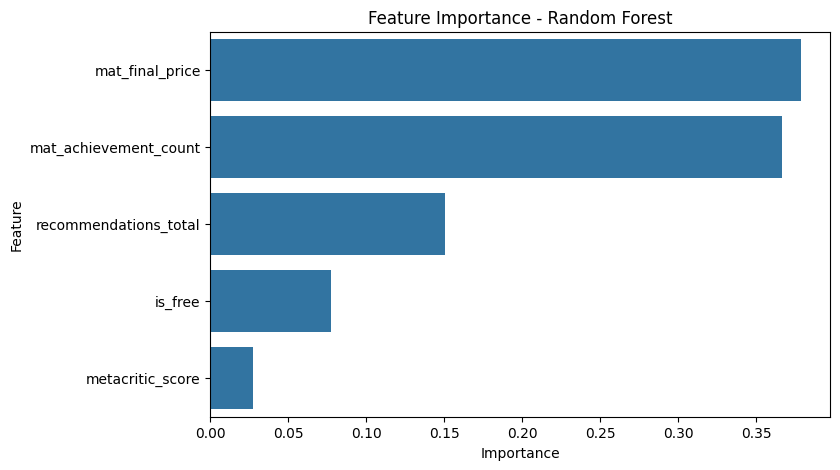

In [11]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="importance",
    y="feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 10. Permutation Importance

Permutation Importance đánh giá tầm quan trọng của feature bằng cách tráo ngẫu nhiên giá trị của từng feature, sau đó quan sát mức giảm hiệu suất của mô hình.

Nếu tráo một feature làm hiệu suất giảm nhiều, feature đó có vai trò quan trọng đối với mô hình.

In [12]:
perm_result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "feature": features,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values(by="importance_mean", ascending=False)

perm_importance

,feature,importance_mean,importance_std
3,mat_achievement_count,0.022386,0.000954
1,metacritic_score,-0.002591,0.000135
2,recommendations_total,-0.003075,0.000295
4,mat_final_price,-0.004310,0.000979
0,is_free,-0.030806,0.000609


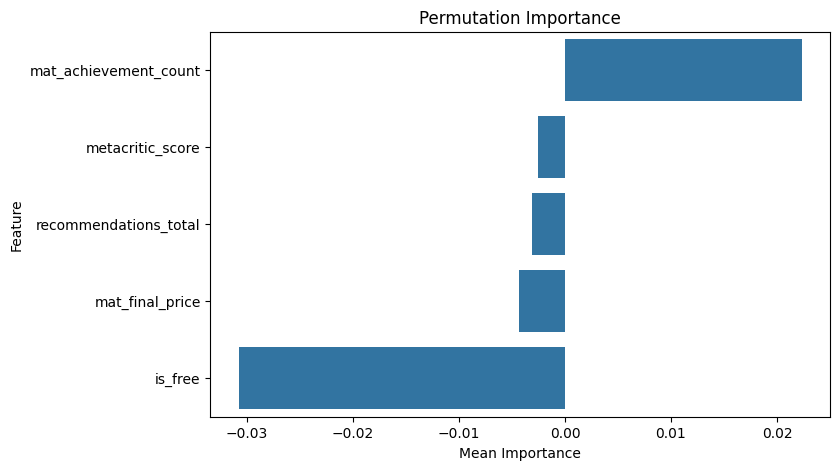

In [13]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=perm_importance,
    x="importance_mean",
    y="feature"
)

plt.title("Permutation Importance")
plt.xlabel("Mean Importance")
plt.ylabel("Feature")

plt.show()

## 11. Compare Feature Importance and Permutation Importance

Bảng dưới đây giúp so sánh kết quả từ hai cách giải thích mô hình.  
Feature Importance là độ quan trọng nội tại của Random Forest, còn Permutation Importance kiểm tra mức ảnh hưởng thực tế khi tráo từng feature.

In [14]:
importance_comparison = feature_importance.merge(
    perm_importance,
    on="feature",
    how="inner"
)

importance_comparison

,feature,importance,importance_mean,importance_std
0,mat_final_price,0.378514,-0.004310,0.000979
1,mat_achievement_count,0.366535,0.022386,0.000954
2,recommendations_total,0.150445,-0.003075,0.000295
3,is_free,0.077184,-0.030806,0.000609
4,metacritic_score,0.027323,-0.002591,0.000135


# Final Conclusion

- Dữ liệu được lấy từ MySQL thông qua view `vw_applications_ml_base`.

- Mô hình Random Forest Classifier được sử dụng để dự đoán khả năng một game có hỗ trợ Linux hay không (`mat_supports_linux`). Mục đích chính là tạo một mô hình có thể phân tích Feature Importance.

- Target `mat_supports_linux` cần được kiểm tra phân bố vì nếu dữ liệu mất cân bằng, Accuracy có thể cao nhưng chưa phản ánh đầy đủ chất lượng mô hình.

- Accuracy trong đây chỉ được sử dụng như một chỉ số kiểm tra nhanh rằng mô hình đã học được tín hiệu từ data. Các đánh giá classification chi tiết như Precision, Recall, F1-score và Confusion Matrix đã được trình bày ở notebook `04_classification.ipynb`.

- Feature Importance giúp xác định các feature mà Random Forest sử dụng nhiều trong quá trình dự đoán.

- Permutation Importance giúp kiểm tra mức độ ảnh hưởng của từng feature bằng cách tráo ngẫu nhiên giá trị của feature đó và đo mức giảm hiệu suất.

- Việc kết hợp Feature Importance và Permutation Importance giúp tăng tính minh bạch của mô hình, từ đó hỗ trợ hiểu rõ hơn mô hình dựa vào yếu tố nào để đưa ra dự đoán.
